<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE--SUPERVISADO/blob/main/AR_clasification2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arboles de regresión para clasificación

## **Descripción de variables**

Demographic:
- Sex: male or female(Nominal)
- Age: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

Behavioral
- Current Smoker: whether or not the patient is a current smoker (Nominal)
- Cigs Per Day: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)

Medical( history)
- BP Meds: whether or not the patient was on blood pressure medication (Nominal)
- Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
- Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
- Diabetes: whether or not the patient had diabetes (Nominal)
Medical(current)
- Tot Chol: total cholesterol level (Continuous)
- Sys BP: systolic blood pressure (Continuous)
- Dia BP: diastolic blood pressure (Continuous)
- BMI: Body Mass Index (Continuous)
- Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)
- Glucose: glucose level (Continuous)
Predict variable (desired target)
- 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)

*   Target variable (y): TenYearCHD (binary: 1 = will develop CHD, 0 = will not)
*   Features (X): demographic, behavioral, and medical factors

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cargue de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/APREN. SUPERVISADO/framingham.xls')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
 df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


# Limpieza de datos

In [ ]:
df = df.dropna()

In [ ]:
df.shape

(3656, 16)

# Preparación de datos para el modelo

## Revisión de variables a incluir en el modelo

In [ ]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']


## Creación de los subconjuntos de entrenamiento y prueba

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Escalamiento de los datos

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenamiento del modelo de regresión logística

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nConfusion Matrix:")
display(conf_matrix)
print("\nClassification Report:")
print(report)

Accuracy: 0.8469
Precision: 0.6071
Recall: 0.0977
F1-score: 0.1683

Confusion Matrix:


array([[912,  11],
       [157,  17]])


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       923
           1       0.61      0.10      0.17       174

    accuracy                           0.85      1097
   macro avg       0.73      0.54      0.54      1097
weighted avg       0.81      0.85      0.80      1097



## Ecuacion del modelo de regresion logistica

In [ ]:
intercept = model.intercept_[0]
coefficients = model.coef_[0]


coef_series = pd.Series(coefficients, index=X.columns)

print(f"Intercept: {intercept:.4f}")
print("\nCoefficients:")
display(coef_series)

Intercept: -2.0495

Coefficients:


,0
male,0.283994
age,0.567038
education,-0.014856
currentSmoker,0.070603
cigsPerDay,0.236018
BPMeds,0.046160
prevalentStroke,0.107746
prevalentHyp,0.084262
diabetes,0.036641
totChol,0.138072


# El indice de Framingham

El índice de Framingham (o Framingham Risk Score) es un modelo desarrollado a partir del Framingham Heart Study para estimar el riesgo de enfermedad cardiovascular (ECV) a 10 años. Dependiendo de la versión (para enfermedad coronaria, enfermedad cardiovascular global, insuficiencia cardíaca, etc.), se incluyen algunas variaciones de las variables, pero en general las más relevantes son:

Variables principales del modelo clásico (Framingham Risk Score para ECV a 10 años):

- Edad: El riesgo cardiovascular aumenta fuertemente con la edad.
- Sexo: Hombres y mujeres tienen diferente riesgo a igual perfil de factores.
- Colesterol total: Nivel en sangre (mg/dL o mmol/L).
- Colesterol HDL (High Density Lipoprotein): Nivel de colesterol "bueno", que protege contra la aterosclerosis.
- Presión arterial sistólica: Diferencia entre pacientes tratados con antihipertensivos o no tratados.
- Tabaquismo: Indica si la persona fuma actualmente.
- Diabetes mellitus: Presencia de diabetes tipo 2 aumenta significativamente el riesgo.

## Nuevo modelo de regresión

In [ ]:
df.corr()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
male,1.000000,-0.024387,0.017677,0.206778,0.331243,-0.052128,-0.002308,0.000806,0.013833,-0.070229,-0.045484,0.051575,0.072867,-0.114923,0.003048,0.091745
age,-0.024387,1.000000,-0.158961,-0.210862,-0.189099,0.134670,0.050864,0.306693,0.109027,0.267764,0.388551,0.208880,0.137172,-0.002685,0.118245,0.233810
education,0.017677,-0.158961,1.000000,0.025253,0.013527,-0.013647,-0.030353,-0.079100,-0.039547,-0.012956,-0.124511,-0.058502,-0.137280,-0.064254,-0.031874,-0.063068
currentSmoker,0.206778,-0.210862,0.025253,1.000000,0.773819,-0.051936,-0.038159,-0.107561,-0.041859,-0.051119,-0.134371,-0.115748,-0.159574,0.050452,-0.053346,0.019176
cigsPerDay,0.331243,-0.189099,0.013527,0.773819,1.000000,-0.046479,-0.036283,-0.069890,-0.036934,-0.030222,-0.094764,-0.056650,-0.086888,0.063549,-0.053803,0.052159
BPMeds,-0.052128,0.134670,-0.013647,-0.051936,-0.046479,1.000000,0.113119,0.263047,0.049051,0.094011,0.271291,0.199750,0.105603,0.012894,0.054210,0.089116
prevalentStroke,-0.002308,0.050864,-0.030353,-0.038159,-0.036283,0.113119,1.000000,0.066098,0.009619,0.012697,0.061080,0.055878,0.036478,-0.017020,0.016051,0.048351
prevalentHyp,0.000806,0.306693,-0.079100,-0.107561,-0.069890,0.263047,0.066098,1.000000,0.080623,0.167074,0.697790,0.617634,0.302917,0.147333,0.087129,0.181556
diabetes,0.013833,0.109027,-0.039547,-0.041859,-0.036934,0.049051,0.009619,0.080623,1.000000,0.048371,0.102574,0.050767,0.088970,0.060996,0.614817,0.093397
totChol,-0.070229,0.267764,-0.012956,-0.051119,-0.030222,0.094011,0.012697,0.167074,0.048371,1.000000,0.220130,0.174986,0.120799,0.093057,0.049749,0.091127


In [ ]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [ ]:
X = df.drop(['TenYearCHD','education', 'currentSmoker', 'diaBP', 'BMI'], axis=1)
y = df['TenYearCHD']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nConfusion Matrix:")
display(conf_matrix)
print("\nClassification Report:")
print(report)

Accuracy: 0.8487
Precision: 0.6538
Recall: 0.0977
F1-score: 0.1700

Confusion Matrix:


array([[914,   9],
       [157,  17]])


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       923
           1       0.65      0.10      0.17       174

    accuracy                           0.85      1097
   macro avg       0.75      0.54      0.54      1097
weighted avg       0.82      0.85      0.80      1097



## Ajuste del modelo con clases balanceadas

Cuando se tienen clases desbalanceadas, si se entrena la regresión logística, el modelo aprende a minimizar los errores en todos los datos por igual.

Como hay una proporción mayor de pacientes sanos, al modelo le conviene mucho más “acertar” en los sanos.

Entonces, puede “jugar a lo seguro” y predecir casi siempre sano.

Resultado: una precisión aparente alta, pero en realidad detecta mal a los enfermos.

**¿Qué hace class_weight="balanced"?**

Le dice al modelo:

“No todos los errores pesan lo mismo. Si te equivocas con un enfermo, el castigo será más grande, porque hay pocos y son muy importantes”.


**¿Cómo logra eso?**

- Calcula un peso automático para cada clase en función de cuántos ejemplos tiene.

- A las clases con muchos ejemplos (mayoritarias) les da un peso pequeño.

- A las clases con pocos ejemplos (minoritarias) les da un peso grande.


Así, cuando el modelo entrena:

- Un error clasificando a alguien sano se cuenta “normal”.

- Un error clasificando a alguien enfermo se cuenta como si hubieras cometido 5, 6 o más errores (dependiendo del desbalance).


En la práctica esto obliga al modelo a prestar más atención a la clase minoritaria.

Ya no puede ignorarla porque los errores en esa clase le “cuestan muy caro” en la función de pérdida.



## Nuevo modelo con clases balanceadas

In [ ]:
model_balanced = LogisticRegression(class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced')

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions with the balanced model
y_pred_balanced = model_balanced.predict(X_test_scaled)

# Evaluate the balanced model
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
conf_matrix_balanced = confusion_matrix(y_test, y_pred_balanced)
report_balanced = classification_report(y_test, y_pred_balanced)

print("Evaluation of Model with Balanced Class Weights:")
print(f"Accuracy: {accuracy_balanced:.4f}")
print(f"Precision: {precision_balanced:.4f}")
print(f"Recall: {recall_balanced:.4f}")
print(f"F1-score: {f1_balanced:.4f}")
print("\nConfusion Matrix:")
display(conf_matrix_balanced)
print("\nClassification Report:")
print(report_balanced)

Evaluation of Model with Balanced Class Weights:
Accuracy: 0.6746
Precision: 0.2730
Recall: 0.6322
F1-score: 0.3813

Confusion Matrix:


array([[630, 293],
       [ 64, 110]])


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.68      0.78       923
           1       0.27      0.63      0.38       174

    accuracy                           0.67      1097
   macro avg       0.59      0.66      0.58      1097
weighted avg       0.81      0.67      0.72      1097



## Regresion logistica con SMOTE

SMOTE (Synthetic Minority Oversampling Technique) es una técnica para balancear datasets desbalanceados.

En lugar de duplicar ejemplos de la clase minoritaria (lo que puede causar sobreajuste), SMOTE crea nuevos ejemplos sintéticos de esa clase.

Para cada punto minoritario, SMOTE busca sus vecinos más cercanos (otros puntos minoritarios).

Luego, toma un vecino y genera un nuevo punto en el medio del espacio entre ambos (con un valor interpolado).

Así crea ejemplos “realistas” que aumentan la representación de la clase minoritaria.

In [ ]:
!pip install imblearn

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


lr_smote = LogisticRegression(random_state=42)
lr_smote.fit(X_train_resampled, y_train_resampled)


y_pred_smote = lr_smote.predict(X_test_scaled)
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]


print("Evaluation of Logistic Regression Model with SMOTE:")
print("\nConfusion Matrix:")
display(confusion_matrix(y_test, y_pred_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_smote):.4f}")

Evaluation of Logistic Regression Model with SMOTE:

Confusion Matrix:


array([[633, 290],
       [ 62, 112]])


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.69      0.78       923
           1       0.28      0.64      0.39       174

    accuracy                           0.68      1097
   macro avg       0.59      0.66      0.59      1097
weighted avg       0.81      0.68      0.72      1097

ROC-AUC: 0.7062


# Regresion logistica con penalidad

In [ ]:
penalties = ["l1", "l2", "elasticnet"]
solvers = {"l1": "saga", "l2": "lbfgs", "elasticnet": "saga"}  # cada penalización requiere solver compatible

for pen in penalties:
    if pen == "elasticnet":
        model = LogisticRegression(penalty=pen, solver=solvers[pen],
                                   l1_ratio=0.5,   # mezcla entre L1 y L2
                                   max_iter=5000,
                                   random_state=42)
    else:
        model = LogisticRegression(penalty=pen, solver=solvers[pen],
                                   max_iter=5000,
                                   random_state=42)

    # Entrenar
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n=== Penalización: {pen.upper()} ===")
    print(classification_report(y_test, y_pred, digits=4))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))


=== Penalización: L1 ===
              precision    recall  f1-score   support

           0     0.8440    0.9967    0.9141       923
           1     0.5714    0.0230    0.0442       174

    accuracy                         0.8423      1097
   macro avg     0.7077    0.5099    0.4791      1097
weighted avg     0.8008    0.8423    0.7761      1097

Matriz de confusión:
[[920   3]
 [170   4]]

=== Penalización: L2 ===
              precision    recall  f1-score   support

           0     0.8533    0.9892    0.9162       923
           1     0.6296    0.0977    0.1692       174

    accuracy                         0.8478      1097
   macro avg     0.7415    0.5434    0.5427      1097
weighted avg     0.8178    0.8478    0.7977      1097

Matriz de confusión:
[[913  10]
 [157  17]]

=== Penalización: ELASTICNET ===
              precision    recall  f1-score   support

           0     0.8440    0.9967    0.9141       923
           1     0.5714    0.0230    0.0442       174

    accu

## Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Evaluate the Random Forest model
print("Evaluation of Random Forest Model:")
print("\nConfusion Matrix:")
display(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Get predicted probabilities for ROC-AUC
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

Evaluation of Random Forest Model:

Confusion Matrix:


array([[901,  22],
       [159,  15]])


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       923
           1       0.41      0.09      0.14       174

    accuracy                           0.84      1097
   macro avg       0.63      0.53      0.53      1097
weighted avg       0.78      0.84      0.79      1097

ROC-AUC: 0.6833


## Random forest mejorado

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest model
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Evaluate the Random Forest model
print("Evaluation of Random Forest Model:")
print("\nConfusion Matrix:")
display(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Get predicted probabilities for ROC-AUC
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

Evaluation of Random Forest Model:

Confusion Matrix:


array([[918,   5],
       [162,  12]])


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       923
           1       0.71      0.07      0.13       174

    accuracy                           0.85      1097
   macro avg       0.78      0.53      0.52      1097
weighted avg       0.83      0.85      0.79      1097

ROC-AUC: 0.6850


## Gradient boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Train a Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Evaluate the Gradient Boosting model
print("Evaluation of Gradient Boosting Model:")
print("\nConfusion Matrix:")
display(confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

# Get predicted probabilities for ROC-AUC
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}")

Evaluation of Gradient Boosting Model:

Confusion Matrix:


array([[904,  19],
       [155,  19]])


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       923
           1       0.50      0.11      0.18       174

    accuracy                           0.84      1097
   macro avg       0.68      0.54      0.55      1097
weighted avg       0.80      0.84      0.80      1097

ROC-AUC: 0.6886


In [ ]:
df = pd.read_csv('/content/framingham.xls')

FileNotFoundError: [Errno 2] No such file or directory: '/content/framingham.xls'

In [ ]:
from sklearn.model_selection import train_test_split

X = df.select_dtypes(include=['number']).drop('TenYearCHD', axis=1)
y = df['TenYearCHD']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully!")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets successfully!
Shape of X_train: (2924, 15)
Shape of X_test: (732, 15)
Shape of y_train: (2924,)
Shape of y_test: (732,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(class_weight='balanced',random_state=42, max_depth=5)
model.fit(X_train, y_train)

print("Decision tree classifier model trained successfully!")

Decision tree classifier model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.6995
Precision: 0.2793
Recall: 0.5082
F1-score: 0.3605


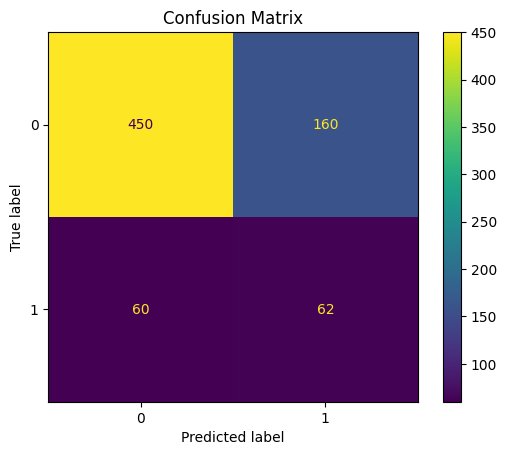

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.title('Confusion Matrix')
plt.show()